In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
df = pd.DataFrame()

In [3]:
df["X1"] = [1,2,3,4,5,6,6,7,9,9]
df["X2"] = [5,3,6,8,1,9,5,8,9,2]
df["target"] = [1,1,0,1,0,1,0,1,0,0]

In [5]:
df

,X1,X2,target
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


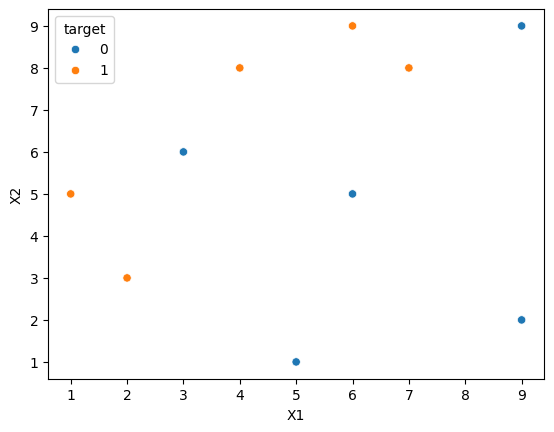

In [8]:
sns.scatterplot(df, x = "X1", y="X2", hue="target")
plt.show()

In [9]:
df["weights"] = 1/df.shape[0]

In [10]:
df.head()

,X1,X2,target,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1


In [12]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [13]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [15]:
y

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 0], dtype=int64)

In [18]:
# step 2 train the first 

In [19]:
dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]')]

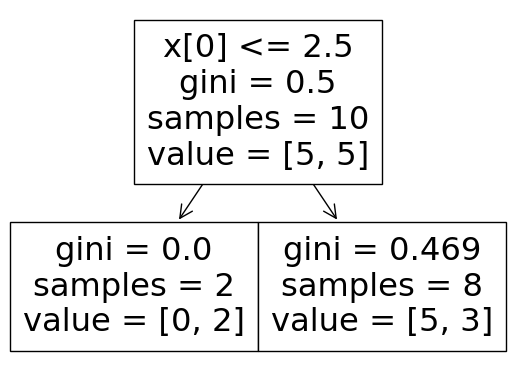

In [21]:
plot_tree(dt1)

<Axes: >

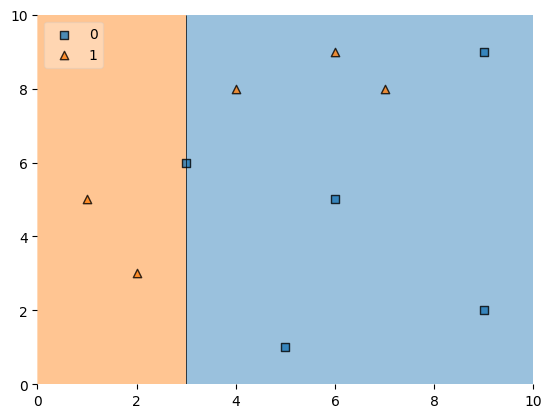

In [22]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [23]:
df["y_pred"] = dt1.predict(X)

In [24]:
df

,X1,X2,target,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [65]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.0000001))

In [26]:
# step 3 calculate model weight

In [91]:
alpha1 = calculate_model_weight(0.3)

In [92]:
alpha1

0.4236487635269629

In [28]:
# step 4 update the weights

In [43]:
def update_weights(row, alpha=0.423):
    if row["target"] == row["y_pred"]:
        return row["weights"] * np.exp(-alpha)
    else:
        return row["weights"] * np.exp(alpha)

In [44]:
df["updated_weights"] = df.apply(update_weights, axis=1)

In [45]:
df

,X1,X2,target,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [46]:
df["updated_weights"].sum()

0.9165153319682015

In [47]:
df["normalized_weights"] = df["updated_weights"]/df["updated_weights"].sum()

In [48]:
df["normalized_weights"].sum()

1.0

In [49]:
df

,X1,X2,target,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [50]:
df["cumsum_upper"] = np.cumsum(df["normalized_weights"])
df["cumsum_lower"] = df["cumsum_upper"] - df["normalized_weights"]

In [51]:
df

,X1,X2,target,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,0,0.065508,0.071475,0.214425,0.142950
3,4,8,1,0.1,0,0.152653,0.166559,0.380983,0.214425
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,0,0.152653,0.166559,0.619017,0.452458
6,6,5,0,0.1,0,0.065508,0.071475,0.690492,0.619017
7,7,8,1,0.1,0,0.152653,0.166559,0.857050,0.690492
8,9,9,0,0.1,0,0.065508,0.071475,0.928525,0.857050
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [52]:
df[["X1", "X2", "target", "weights", "y_pred", "updated_weights", "normalized_weights", "cumsum_lower", "cumsum_upper"]]

,X1,X2,target,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.071475,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.166559,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.071475,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.166559,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.071475,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.166559,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.071475,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.071475,0.928525,1.000000


In [53]:
def creat_new_dataset(df):

    indicies = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row["cumsum_upper"] > a and a > row["cumsum_lower"]:
                indicies.append(index)
    return indicies

In [54]:
index_values = creat_new_dataset(df)

In [55]:
index_values

[5, 3, 5, 3, 5, 3, 3, 1, 9, 9]

In [56]:
second_df = df.iloc[index_values, [0,1,2,3]]

In [57]:
second_df

,X1,X2,target,weights
5,6,9,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
9,9,2,0,0.1
9,9,2,0,0.1


In [58]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [59]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
dt2.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]')]

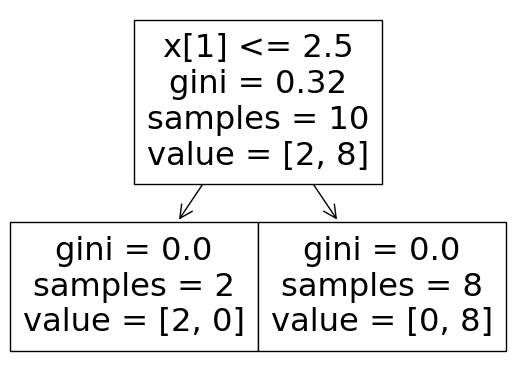

In [60]:
plot_tree(dt2)

<Axes: >

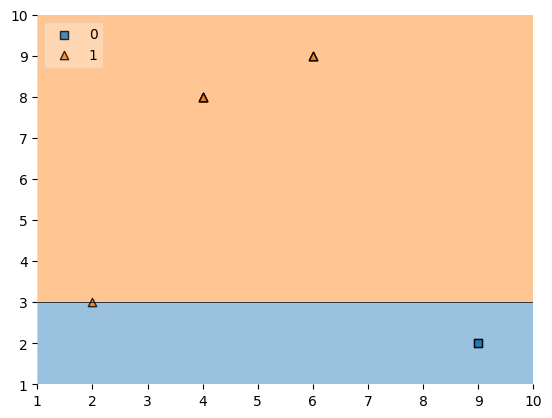

In [61]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [62]:
second_df["y_pred"] = dt2.predict(X)

In [63]:
second_df

,X1,X2,target,weights,y_pred
5,6,9,1,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,1
3,4,8,1,0.1,1
5,6,9,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
1,2,3,1,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0


In [66]:
alpha2 = calculate_model_weight(0)

In [67]:
alpha2

8.05904782547916

In [68]:
def update_weights(row, alpha=8.059):
    if row["target"] == row["y_pred"]:
        return row["weights"] * np.exp(-alpha)
    else:
        return row["weights"] * np.exp(alpha)

In [69]:
second_df["updated_weights"] = df.apply(update_weights, axis=1)

In [70]:
second_df

,X1,X2,target,weights,y_pred,updated_weights
5,6,9,1,0.1,1,316.212643
3,4,8,1,0.1,1,316.212643
5,6,9,1,0.1,1,316.212643
3,4,8,1,0.1,1,316.212643
5,6,9,1,0.1,1,316.212643
3,4,8,1,0.1,1,316.212643
3,4,8,1,0.1,1,316.212643
1,2,3,1,0.1,1,0.000032
9,9,2,0,0.1,0,0.000032
9,9,2,0,0.1,0,0.000032


In [71]:
second_df["normalized_weights"] = second_df["updated_weights"]/second_df["updated_weights"].sum()

In [72]:
second_df

,X1,X2,target,weights,y_pred,updated_weights,normalized_weights
5,6,9,1,0.1,1,316.212643,1.428571e-01
3,4,8,1,0.1,1,316.212643,1.428571e-01
5,6,9,1,0.1,1,316.212643,1.428571e-01
3,4,8,1,0.1,1,316.212643,1.428571e-01
5,6,9,1,0.1,1,316.212643,1.428571e-01
3,4,8,1,0.1,1,316.212643,1.428571e-01
3,4,8,1,0.1,1,316.212643,1.428571e-01
1,2,3,1,0.1,1,0.000032,1.428708e-08
9,9,2,0,0.1,0,0.000032,1.428708e-08
9,9,2,0,0.1,0,0.000032,1.428708e-08


In [73]:
second_df["normalized_weights"].sum()

1.0

In [78]:
second_df["cumsum_upper"] = np.cumsum(second_df["normalized_weights"])
second_df["cumsum_lower"] = second_df["cumsum_upper"] - second_df["normalized_weights"]

In [79]:
second_df[["X1", "X2", "target", "weights", "y_pred", "updated_weights", "normalized_weights", "cumsum_lower", "cumsum_upper"]]

,X1,X2,target,weights,y_pred,updated_weights,normalized_weights,cumsum_lower,cumsum_upper
5,6,9,1,0.1,1,316.212643,1.428571e-01,0.000000,0.142857
3,4,8,1,0.1,1,316.212643,1.428571e-01,0.142857,0.285714
5,6,9,1,0.1,1,316.212643,1.428571e-01,0.285714,0.428571
3,4,8,1,0.1,1,316.212643,1.428571e-01,0.428571,0.571429
5,6,9,1,0.1,1,316.212643,1.428571e-01,0.571429,0.714286
3,4,8,1,0.1,1,316.212643,1.428571e-01,0.714286,0.857143
3,4,8,1,0.1,1,316.212643,1.428571e-01,0.857143,1.000000
1,2,3,1,0.1,1,0.000032,1.428708e-08,1.000000,1.000000
9,9,2,0,0.1,0,0.000032,1.428708e-08,1.000000,1.000000
9,9,2,0,0.1,0,0.000032,1.428708e-08,1.000000,1.000000


In [80]:
index_values = creat_new_dataset(second_df)

In [81]:
index_values

[3, 5, 3, 5, 3, 5, 5, 5, 5, 3]

In [82]:
third_df = second_df.iloc[index_values, [0,1,2,3]]

In [83]:
third_df

,X1,X2,target,weights
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1


In [84]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = third_df.iloc[:, 0:2].values
y = third_df.iloc[:,2].values

dt3.fit(X, y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.5, 'gini = 0.0\nsamples = 10\nvalue = 1.0')]

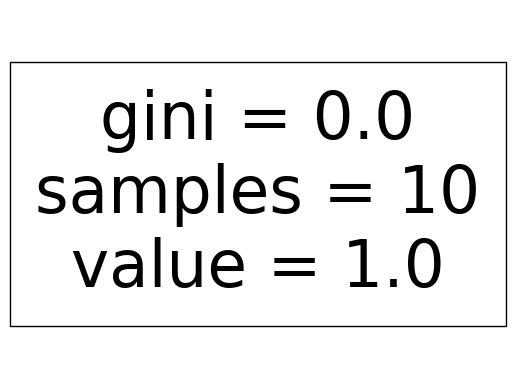

In [85]:
plot_tree(dt3)

<Axes: >

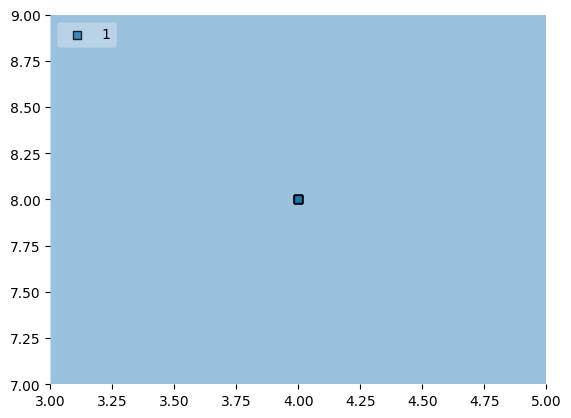

In [86]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [87]:
third_df["y_pred"] = dt3.predict(X)

In [88]:
third_df

,X1,X2,target,weights,y_pred
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,1


In [89]:
alpha3 = calculate_model_weight(0)

In [90]:
alpha3

8.05904782547916

In [93]:
print(alpha1, alpha2, alpha3)

0.4236487635269629 8.05904782547916 8.05904782547916


# Prediction

In [96]:
query = np.array([1, 5]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [97]:
query = np.array([1, 5]).reshape(1,2)
dt2.predict(query)

array([1], dtype=int64)

In [98]:
query = np.array([1, 5]).reshape(1,2)
dt3.predict(query)

array([1], dtype=int64)

In [104]:
alpha1*1 + alpha2*1 + alpha3*1

16.541744414485283

In [105]:
np.sign(16.54)

1.0

In [101]:
query = np.array([9, 9]).reshape(1,2)
dt1.predict(query)

array([0], dtype=int64)

In [102]:
query = np.array([9, 9]).reshape(1,2)
dt2.predict(query)

array([1], dtype=int64)

In [103]:
query = np.array([9, 9]).reshape(1,2)
dt3.predict(query)

array([1], dtype=int64)

In [107]:
alpha1*(-1) + alpha2*1 

7.635399061952198